In [1]:
# Cell 1: Imports and loading data
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Paths
DATA_DIR = "../data/processed"
X_path = os.path.join(DATA_DIR, "X_tfidf.pkl")
y_path = os.path.join(DATA_DIR, "y.pkl")
MODEL_PATH = os.path.join(DATA_DIR, "logreg_model.pkl")

print("Loading TF-IDF features and labels...")
X = joblib.load(X_path)
y = joblib.load(y_path)
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Loading TF-IDF features and labels...
Features shape: (40432, 5000)
Labels shape: (40432,)


In [3]:
# Cell 2: Train/test split (stratify to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 32345, Testing samples: 8087


In [4]:
# Cell 3: Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
print("Training Logistic Regression...")
log_reg.fit(X_train, y_train)
print("Training completed.")

Training Logistic Regression...
Training completed.



Accuracy: 0.8916

Classification Report:
              precision    recall  f1-score   support

   Real (OR)       0.89      0.90      0.89      4044
   Fake (CG)       0.89      0.89      0.89      4043

    accuracy                           0.89      8087
   macro avg       0.89      0.89      0.89      8087
weighted avg       0.89      0.89      0.89      8087



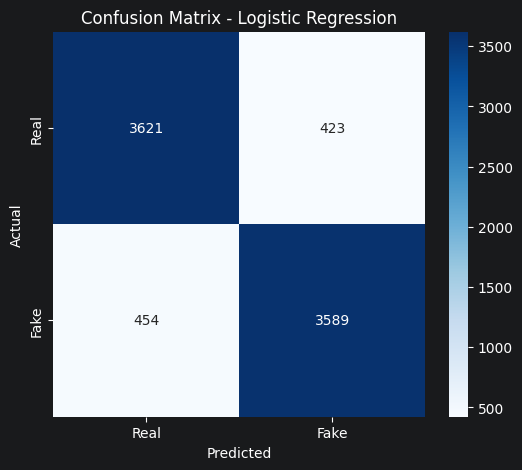

In [5]:
# Cell 4: Predictions and evaluation
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Real (OR)", "Fake (CG)"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [6]:
# Cell 5: Save the model for GUI integration
joblib.dump(log_reg, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to ../data/processed\logreg_model.pkl


In [7]:
# Cell 6 (optional): Inspect top features (coefficients)
vectorizer = joblib.load(os.path.join(DATA_DIR, "tfidf_vectorizer.pkl"))
feature_names = vectorizer.get_feature_names_out()
coef = log_reg.coef_[0]

# Top 10 features for Fake (positive coefficients)
top_fake_idx = np.argsort(coef)[-10:][::-1]
print("Top 10 features indicating FAKE reviews:")
for idx in top_fake_idx:
    print(f"  {feature_names[idx]}: {coef[idx]:.4f}")

# Top 10 features for Real (negative coefficients)
top_real_idx = np.argsort(coef)[:10]
print("\nTop 10 features indicating REAL reviews:")
for idx in top_real_idx:
    print(f"  {feature_names[idx]}: {coef[idx]:.4f}")


Top 10 features indicating FAKE reviews:
  reason gave: 4.9944
  admit: 4.9444
  reason: 4.7071
  problem really: 4.7030
  wide: 4.6762
  also love: 4.6537
  replace: 4.5411
  bought friend: 4.4704
  downside: 4.3063
  couple: 4.0846

Top 10 features indicating REAL reviews:
  even: -5.7653
  though: -4.6844
  without: -4.1771
  much: -4.0000
  however: -3.6493
  end: -3.6282
  another: -3.4425
  actually: -3.3227
  really: -3.2366
  something: -3.1678
